# Step 1: Load and Filter the Iris Dataset

In this step, we load the Iris dataset, select only class 1 and 2 for a binary classification task, 
and use only "Petal Length" and "Petal Width" features. We also check for missing values.


In [2]:
# Step 1: Load and Filter the Iris Dataset
import pandas as pd
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)

# Select only classes 0 and 1 (binary classification)
binary_mask = y.isin([0, 1])
X = X[binary_mask]
y = y[binary_mask]

# Select only Petal Length and Petal Width
X = X[['petal length (cm)', 'petal width (cm)']]

# Check for missing values
missing_values = X.isnull().sum()
print("Missing values in each feature:\n", missing_values)

# Display the first few rows
X.head(), y.head()


Missing values in each feature:
 petal length (cm)    0
petal width (cm)     0
dtype: int64


(   petal length (cm)  petal width (cm)
 0                1.4               0.2
 1                1.4               0.2
 2                1.3               0.2
 3                1.5               0.2
 4                1.4               0.2,
 0    0
 1    0
 2    0
 3    0
 4    0
 dtype: int64)

# Step 2: Standardize and Split the Dataset

In this step, we standardize the features so that each has zero mean and unit variance. 
Standardization is crucial for SVM since it is sensitive to feature scales. 

After standardization, we split the dataset into three sets:
- Training set (80%)
- Validation set (10%)
- Test set (10%)

We use a fixed random state for reproducibility.


In [3]:
# Step 2: Standardize and Split the Dataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into Train (80%) + Temp (20%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Split Temp into Validation (10%) and Test (10%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Print dataset shapes
print("Train set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)


Train set: (80, 2) (80,)
Validation set: (10, 2) (10,)
Test set: (10, 2) (10,)


# Step 3: Train Linear SVM with Different C Values

In this step, we train a linear SVM for multiple values of the regularization parameter `C`:

C = [0.01, 0.1, 1, 10, 100]

For each value of C:
- Train the SVM on the training set
- Record training time
- Record the number of support vectors
- Evaluate accuracy on training and test sets

This allows us to analyze how the `C` parameter affects model complexity, performance, and training time.


In [4]:
# Step 3: Train Linear SVM with Different C Values
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import time
import pandas as pd

# Define C values
C_values = [0.01, 0.1, 1, 10, 100]

# DataFrame to store results
results = pd.DataFrame(columns=['C', 'Train Accuracy', 'Test Accuracy', 'Training Time', 'Num Support Vectors'])

for C in C_values:
    # Create Linear SVM model
    svm_model = SVC(kernel='linear', C=C, random_state=42)
    
    # Train model and measure time
    start_time = time.time()
    svm_model.fit(X_train, y_train)
    end_time = time.time()
    
    training_time = end_time - start_time
    
    # Predictions
    y_train_pred = svm_model.predict(X_train)
    y_test_pred = svm_model.predict(X_test)
    
    # Calculate accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    # Number of support vectors
    num_sv = svm_model.n_support_.sum()
    
    # Store results
    results = pd.concat([results, pd.DataFrame({
        'C': [C],
        'Train Accuracy': [train_acc],
        'Test Accuracy': [test_acc],
        'Training Time': [training_time],
        'Num Support Vectors': [num_sv]
    })], ignore_index=True)

# Display results
results


C:\Users\busin\AppData\Local\Temp\ipykernel_9892\4162071251.py:36: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, pd.DataFrame({


,C,Train Accuracy,Test Accuracy,Training Time,Num Support Vectors
0,0.01,1.0,1.0,0.009043,56
1,0.10,1.0,1.0,0.006674,12
2,1.00,1.0,1.0,0.005745,2
3,10.00,1.0,1.0,0.005302,2
4,100.00,1.0,1.0,0.001751,2


# Step 4: Plot Decision Boundaries for Different C Values

In this step, we visualize the decision boundary of the linear SVM for each value of C. 
We plot:
- Training data points
- Decision boundary
- Support vectors (highlighted)

This allows us to analyze how changing C affects model complexity and overfitting.


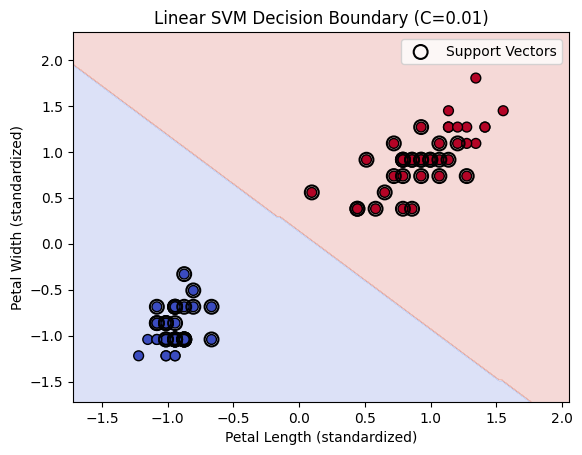

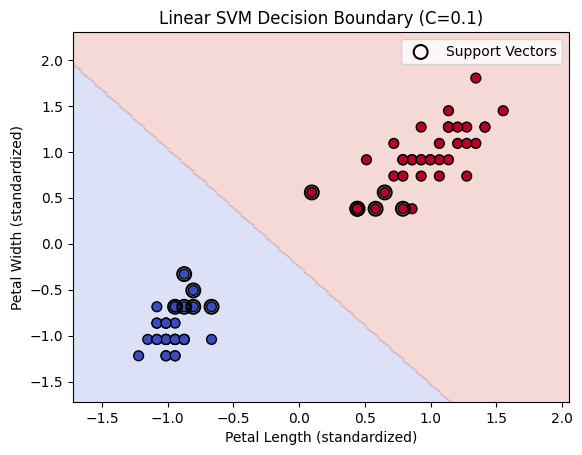

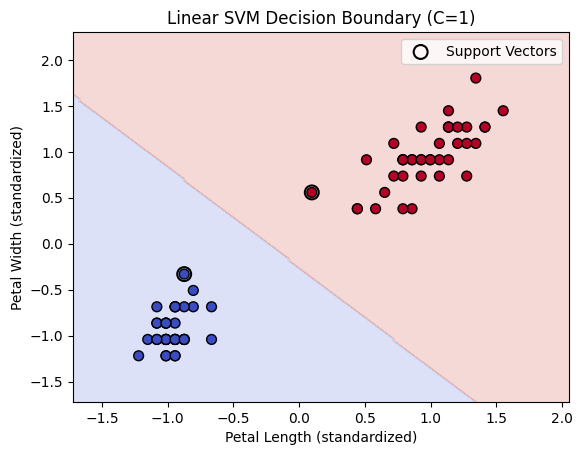

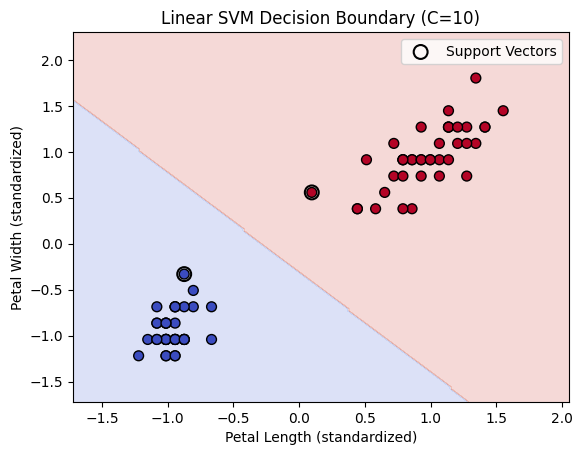

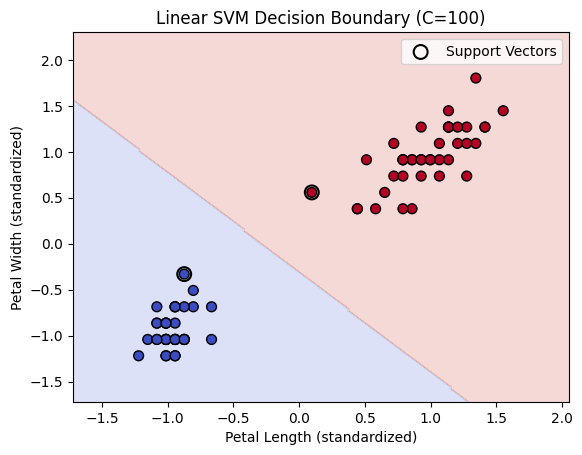

In [5]:
# Step 4: Plot Decision Boundaries for Different C Values
import matplotlib.pyplot as plt
import numpy as np

# Define a function to plot decision boundary
def plot_decision_boundary(model, X, y, title):
    # Create a mesh grid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    # Predict over the grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot contour
    plt.contourf(xx, yy, Z, alpha=0.2, cmap=plt.cm.coolwarm)
    
    # Plot training points
    plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap=plt.cm.coolwarm, edgecolors='k')
    
    # Highlight support vectors
    sv = model.support_vectors_
    plt.scatter(sv[:, 0], sv[:, 1], s=100, facecolors='none', edgecolors='k', linewidths=1.5, label='Support Vectors')
    
    plt.xlabel('Petal Length (standardized)')
    plt.ylabel('Petal Width (standardized)')
    plt.title(title)
    plt.legend()
    plt.show()

# Plot decision boundary for each C
for C in C_values:
    svm_model = SVC(kernel='linear', C=C, random_state=42)
    svm_model.fit(X_train, y_train)
    plot_decision_boundary(svm_model, X_train, y_train, title=f'Linear SVM Decision Boundary (C={C})')


# Step 5: Numerical Analysis of Results

In this step, we analyze the numerical results obtained from training different SVM models.
We compare:
- Training accuracy
- Test accuracy
- Training time
- Number of support vectors

This helps us understand how the regularization parameter C affects model performance.


In [6]:
# Step 5: Numerical Analysis

# Sort results by C
results_sorted = results.sort_values(by='C')
results_sorted


,C,Train Accuracy,Test Accuracy,Training Time,Num Support Vectors
0,0.01,1.0,1.0,0.009043,56
1,0.10,1.0,1.0,0.006674,12
2,1.00,1.0,1.0,0.005745,2
3,10.00,1.0,1.0,0.005302,2
4,100.00,1.0,1.0,0.001751,2


# Step 6: Plot Performance Metrics vs C

In this step, we plot different metrics as a function of C:
- Accuracy vs C
- Training time vs C
- Number of support vectors vs C

These plots reveal how model complexity changes with C.


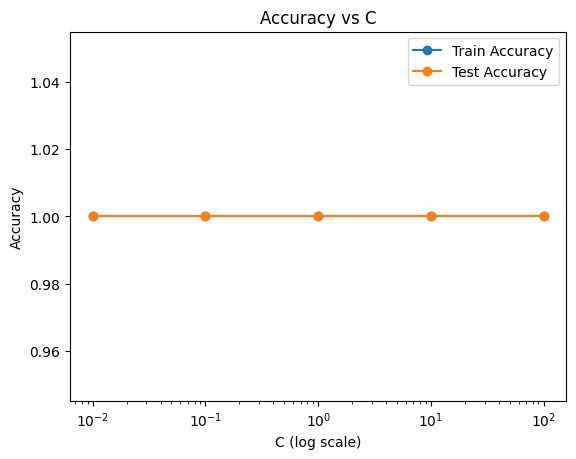

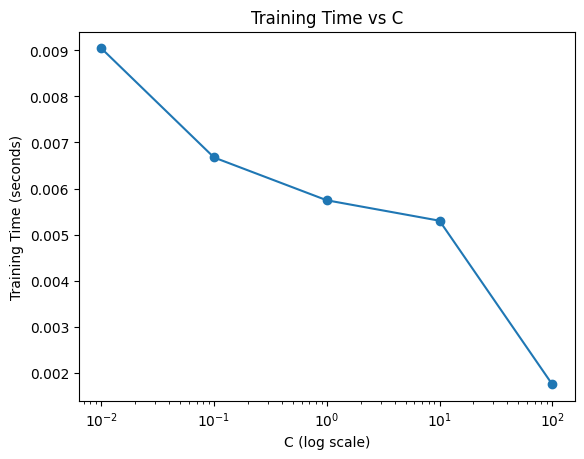

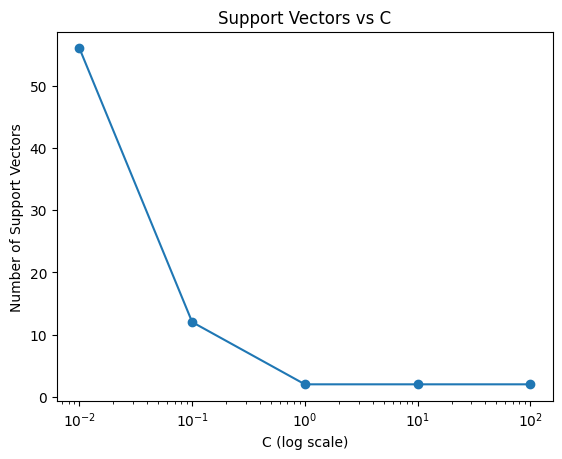

In [7]:
# Step 6: Plot metrics

import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure()
plt.plot(results_sorted['C'], results_sorted['Train Accuracy'], label='Train Accuracy', marker='o')
plt.plot(results_sorted['C'], results_sorted['Test Accuracy'], label='Test Accuracy', marker='o')
plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs C')
plt.legend()
plt.show()

# Plot Training Time
plt.figure()
plt.plot(results_sorted['C'], results_sorted['Training Time'], marker='o')
plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Training Time (seconds)')
plt.title('Training Time vs C')
plt.show()

# Plot Number of Support Vectors
plt.figure()
plt.plot(results_sorted['C'], results_sorted['Num Support Vectors'], marker='o')
plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Number of Support Vectors')
plt.title('Support Vectors vs C')
plt.show()
